# 📊 Unemployment Analysis in India

## 🎯 Objective
The goal of this project was to analyze unemployment trends in India using data science techniques and build a simple predictive model to estimate unemployment rates.

---

## 📂 Dataset Overview
- The dataset contains information about unemployment in various regions of India.
- Key features include:
  - **Region**
  - **Date**
  - **Frequency**
  - **Estimated Unemployment Rate (%)**
  - **Estimated Employed**
  - **Estimated Labour Participation Rate (%)**
  - **Area** (Urban/Rural)

---

## 🔍 Exploratory Data Analysis (EDA)

### Unemployment Trends Over Time
- The unemployment rate saw a sharp increase during the COVID-19 period.
- The line graph showed fluctuations in unemployment levels month by month.

### Regional Analysis
- Some regions consistently showed higher unemployment than others.
- Urban areas were more affected than rural ones in certain time frames.
- A bar chart was used to compare average unemployment across regions.

### Heatmap Insights
- A heatmap revealed how unemployment varied over months and across regions.
- Certain states experienced seasonally high unemployment, especially during lockdown phases.

---

## 🧠 Machine Learning Model Summary

### Model Used
- **Linear Regression** was used to predict unemployment rates.

### Features Selected
- Estimated Employed
- Labour Participation Rate
- Encoded Region
- Encoded Area

### Model Performance
- The model achieved a reasonable **R² Score**, indicating it could moderately predict unemployment based on the selected features.
- Although not perfect, it showed how socioeconomic indicators relate to unemployment levels.

---

## ✅ Conclusion
- Unemployment rates in India changed significantly during COVID-19, with sharp spikes visible in several states.
- This analysis highlighted which regions need more support and job creation.
- The project demonstrated how simple data and visualization can provide powerful insights into national issues.
- The predictive model gave a foundational approach to forecasting unemployment, but better results could be achieved with more complex models and richer datasets.

---

## 🚀 Future Scope
- Use more advanced models like Random Forest, XGBoost, or time-series forecasting methods.
- Add features like education level, income, or age group to improve accuracy.
- Create an interactive dashboard to visualize unemployment trends for policymakers and the public.

---

*Project completed by AZKA.*


In [5]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For better visuals
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# 2. Load the dataset
df = pd.read_csv(r'C:\Users\Dell\Desktop\VS_ML\Models\Unemployment_Analysis\data\Unemployment in India.csv')  # Replace with your actual file
df.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
import os
print(os.getcwd())

c:\Users\Dell\Desktop\VS_ML\Models\Unemployment_Analysis\code


In [6]:
print(df.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [7]:
# Check basic info
print("Shape of dataset:", df.shape)
print("\nColumn Names:\n", df.columns)

# Check for null values
print("\nMissing values:\n", df.isnull().sum())

# View data types
print("\nData types:\n", df.dtypes)

# View unique values in key columns (like State or Date)
print("\nUnique States:\n", df['Region'].unique())
print("\nUnique Dates:\n", df[' Date'].unique())


Shape of dataset: (768, 7)

Column Names:
 Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Missing values:
 Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

Data types:
 Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object

Unique States:
 

In [8]:
# Convert Date column to datetime
df[' Date'] = pd.to_datetime(df[' Date'])

# Fill or drop missing values
df = df.dropna()  # Or you can use df.fillna(method='ffill') if more appropriate

# Rename columns if needed (optional)
df.rename(columns={'Estimated Unemployment Rate (%)': 'Unemployment_Rate'}, inplace=True)


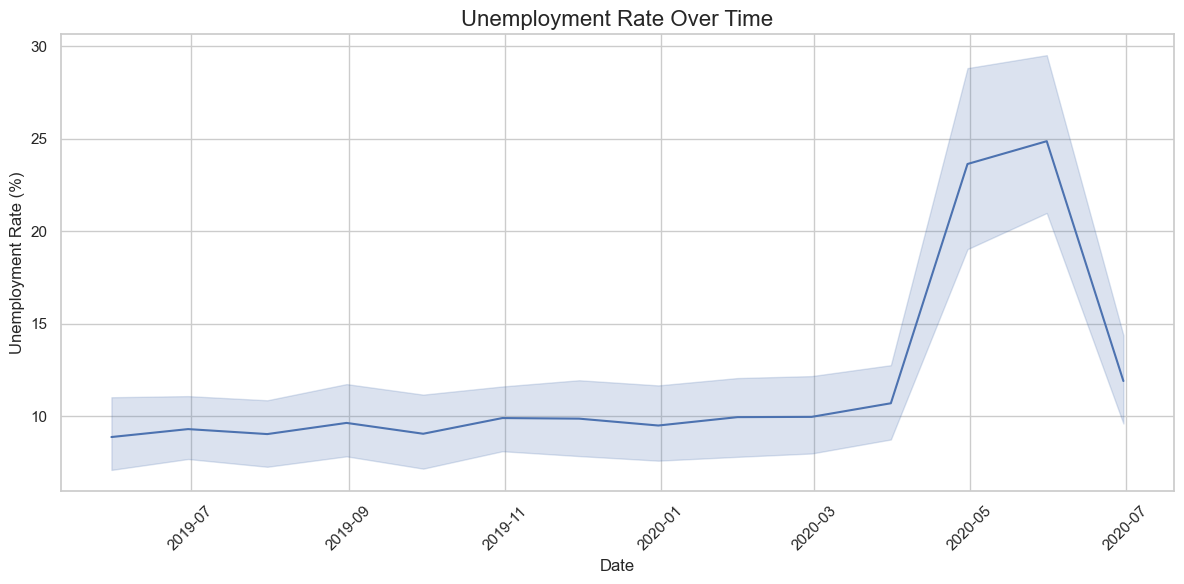

In [10]:
# Line plot of overall unemployment trend
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x=' Date', y=' Estimated Unemployment Rate (%)')
plt.title('Unemployment Rate Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


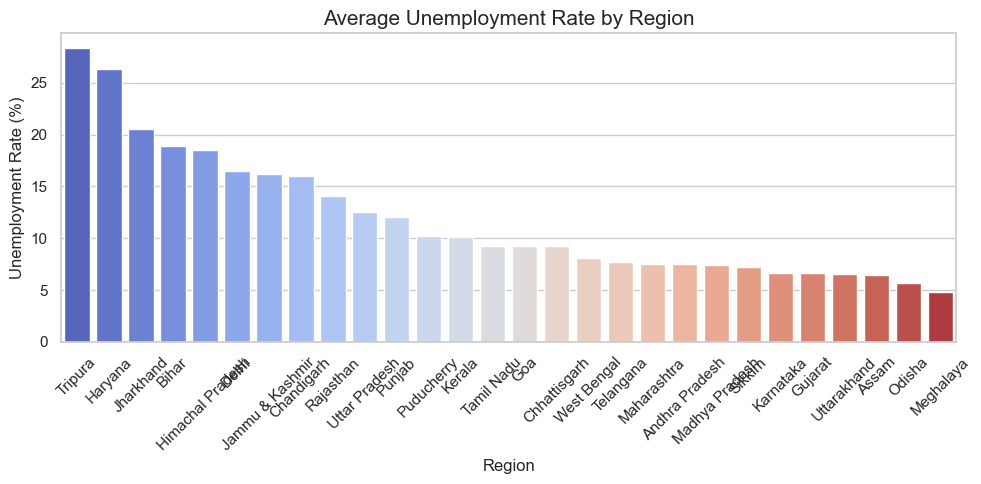

In [11]:
# Bar plot: Average Unemployment by Region
region_avg = df.groupby('Region')[' Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=region_avg.index, y=region_avg.values, palette='coolwarm')
plt.title('Average Unemployment Rate by Region', fontsize=15)
plt.ylabel('Unemployment Rate (%)')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


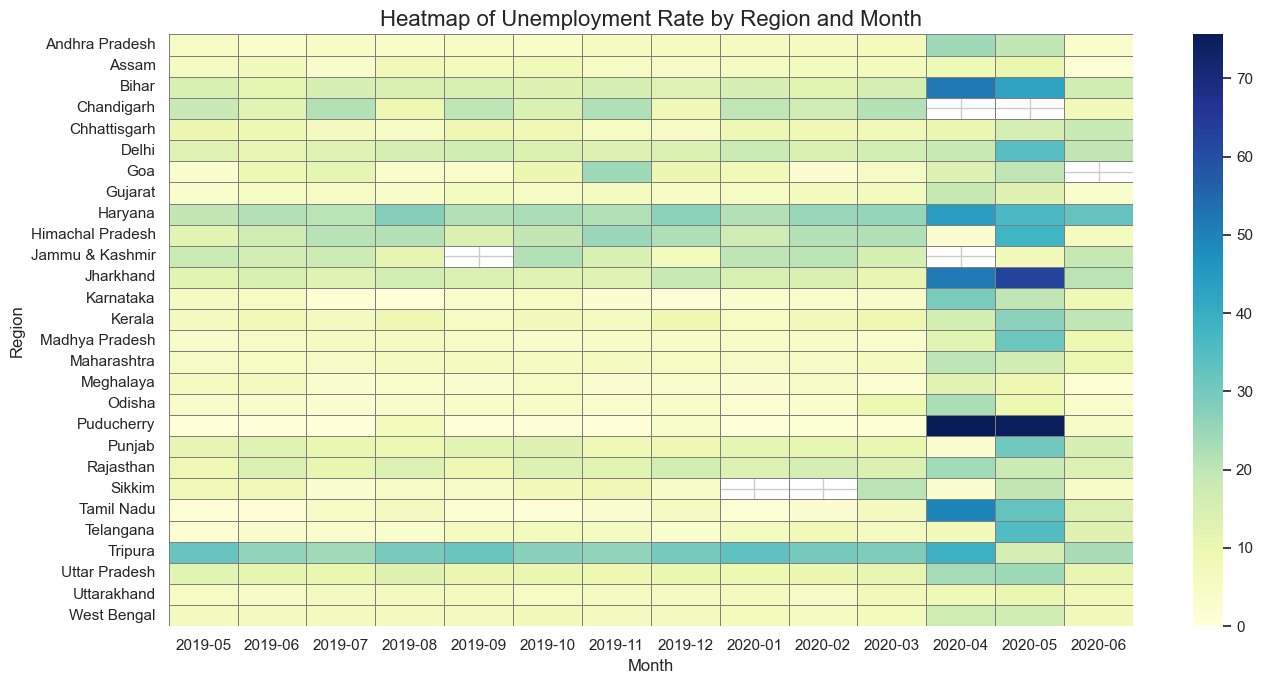

In [12]:
# Add Month column
df['Month'] = df[' Date'].dt.to_period('M')

# Pivot table for heatmap
pivot_table = df.pivot_table(values=' Estimated Unemployment Rate (%)', index='Region', columns='Month')

# Plot heatmap
plt.figure(figsize=(14,7))
sns.heatmap(pivot_table, cmap='YlGnBu', linewidths=0.5, linecolor='gray')
plt.title('Heatmap of Unemployment Rate by Region and Month', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Region')
plt.tight_layout()
plt.show()


In [13]:
from sklearn.preprocessing import LabelEncoder

# Encode 'Region' and 'Area'
le_region = LabelEncoder()
df['Region_encoded'] = le_region.fit_transform(df['Region'])

le_area = LabelEncoder()
df['Area_encoded'] = le_area.fit_transform(df['Area'])


In [14]:
# Define features (X) and target (y)
X = df[[' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Region_encoded', 'Area_encoded']]
y = df[' Estimated Unemployment Rate (%)']


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Mean Squared Error: 137.9216203958711
R2 Score: 0.04735596355543814


In [18]:
import pickle

# Save the model as a pickle file
with open('unemployment_model.pkl', 'wb') as f:
    pickle.dump(model, f)
